# Temporal Convolutional Network (TCN) — Time-Binned Dataset

A **TCN** is a 1D convolutional network with two ingredients that make it a natural fit here:

- **Causal convolutions** — the output at bin *t* only depends on bins *≤ t*, so the model can never peek at the future. This is the leakage guardrail baked straight into the architecture.
- **Dilated convolutions** — stacking layers with dilation 1, 2, 4, 8… grows the receptive field exponentially, so a shallow stack sees a long history cheaply. Unlike an LSTM it trains in parallel (no sequential unrolling), so it's much faster.

**Framing.** Instead of the pre-engineered rolling features the tabular models used, we feed the TCN the *raw per-bin* solar-wind + `ap` values and let it learn the temporal patterns itself. Each training sample is a window of `SEQ_LEN` consecutive 3h bins; the label is `storm_{HORIZON}h` at the window's final bin (a value strictly in the future — the dataset already built it with a forward shift).

The bar to beat, as always on this dataset, is **storm persistence**, not accuracy.

In [ ]:
# Run once. CPU build is fine for this dataset size.
%pip install torch --index-url https://download.pytorch.org/whl/cpu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

In [ ]:
df = pd.read_csv("../data/time_binned_dataset.csv", index_col=0, parse_dates=True).sort_index()
print(df.shape, "|", df.index.min(), "->", df.index.max())

## Config + raw per-bin channels

We reconstruct the raw multivariate time series from the `*_last` columns (each is that bin's actual measured value) plus `ap_now`. These are the physical inputs a TCN should learn from directly — no hand-built rolling stats needed, the convolutions build their own.

In [ ]:
HORIZON  = 12           # 3, 6, 12, or 24
SEQ_LEN  = 16           # trailing bins per window (16 * 3h = 48h of context)
STORM_THRESHOLD = 50    # ap >= 50 ~ Kp 5

CHANNELS = [
    "bz_gsm_nt_last", "b_magnitude_avg_nt_last", "flow_speed_kms_last",
    "proton_density_cm3_last", "flow_pressure_npa_last", "electric_field_mvpm_last",
    "bz_south_last", "ap_now",
]
TARGET_COL = f"storm_{HORIZON}h"

M = df[CHANNELS].values.astype("float32")          # (T, C) raw per-bin values
y = df[TARGET_COL].values.astype("float32")        # (T,)   future storm label at each bin
ap_now = df["ap_now"].values.astype("float32")     # kept raw for the persistence baseline
T, C = M.shape
print(f"{T:,} bins x {C} channels | storm rate {y.mean():.2%}")

## Temporal split, then impute + scale on TRAIN only (guardrails #3, #6)

Split by time (first 80% of bins → train). Channel medians (for the few NaNs) and the standardisation mean/std are computed from **train bins only**, then applied everywhere — the test period never informs the scaler.

In [ ]:
split_row = int(T * 0.8)

# Impute the handful of NaNs with TRAIN medians, then standardise with TRAIN mean/std.
med  = np.nanmedian(M[:split_row], axis=0)
M_i  = np.where(np.isnan(M), med, M)
mean = M_i[:split_row].mean(axis=0)
std  = M_i[:split_row].std(axis=0) + 1e-8
M_s  = (M_i - mean) / std
print("post-scale NaNs:", int(np.isnan(M_s).sum()))

## Build sliding-window sequences

A sample ending at bin *t* is the block `M_s[t-SEQ_LEN+1 : t+1]` (shape `C x SEQ_LEN`) with label `y[t]`. A window belongs to **train** iff it *ends* before the split row, so no training window peeks past the boundary; test windows may reach back into pre-split bins for context (that's past data — not leakage).

In [ ]:
def make_sequences(M_s, y, ap_now, seq_len):
    C = M_s.shape[1]
    Xs, ys, aps, ends = [], [], [], []
    for t in range(seq_len - 1, len(M_s)):
        Xs.append(M_s[t - seq_len + 1 : t + 1].T)   # (C, seq_len)
        ys.append(y[t])
        aps.append(ap_now[t])
        ends.append(t)
    return (np.asarray(Xs, dtype="float32"),
            np.asarray(ys, dtype="float32"),
            np.asarray(aps, dtype="float32"),
            np.asarray(ends))

Xseq, yseq, apseq, ends = make_sequences(M_s, y, ap_now, SEQ_LEN)

tr = ends <  split_row
te = ends >= split_row
X_train, y_train = Xseq[tr], yseq[tr]
X_test,  y_test  = Xseq[te], yseq[te]
ap_test          = apseq[te]

print("train seqs:", X_train.shape, "pos rate", round(y_train.mean(), 4))
print("test seqs: ", X_test.shape,  "pos rate", round(y_test.mean(), 4))

In [ ]:
batch_size = 256
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=512, shuffle=False)

## The TCN

Each `TemporalBlock` is: causal dilated conv → ReLU → dropout, twice, with a residual connection. `Chomp1d` trims the right-side padding so the convolution stays strictly causal (no future leakage). Stacking blocks with dilations 1, 2, 4, 8 gives a receptive field of ~31 bins — enough to cover the 16-bin window. A final linear layer on the last time step produces one storm logit.

In [ ]:
class Chomp1d(nn.Module):
    def __init__(self, chomp): super().__init__(); self.chomp = chomp
    def forward(self, x): return x[:, :, :-self.chomp].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel, dilation, dropout=0.2):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(c_in, c_out, kernel, padding=pad, dilation=dilation),
            Chomp1d(pad), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(c_out, c_out, kernel, padding=pad, dilation=dilation),
            Chomp1d(pad), nn.ReLU(), nn.Dropout(dropout),
        )
        self.down = nn.Conv1d(c_in, c_out, 1) if c_in != c_out else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.down is None else self.down(x)
        return self.relu(out + res)

class TCN(nn.Module):
    def __init__(self, c_in, channels=(32, 32, 32, 32), kernel=3, dropout=0.2):
        super().__init__()
        layers, prev = [], c_in
        for i, ch in enumerate(channels):
            layers.append(TemporalBlock(prev, ch, kernel, dilation=2 ** i, dropout=dropout))
            prev = ch
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(prev, 1)

    def forward(self, x):            # x: (B, C, L)
        h = self.tcn(x)              # (B, ch, L)
        h = h[:, :, -1]              # last time step (B, ch)
        return self.head(h).squeeze(1)   # (B,)

model = TCN(c_in=C).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("trainable params:", n_params)

## Train

`BCEWithLogitsLoss` with `pos_weight = n_neg / n_pos` (~49) up-weights the rare storm class — the TCN analogue of `class_weight='balanced'`. We track train loss and test PR-AUC each epoch.

In [ ]:
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 20

@torch.no_grad()
def predict_proba(model, dl):
    model.eval()
    probs = []
    for xb, _ in dl:
        probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    return np.concatenate(probs)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    train_loss = running / len(train_ds)
    test_pr = average_precision_score(y_test, predict_proba(model, test_dl))
    print(f"epoch {epoch:2d} | train loss {train_loss:.4f} | test PR-AUC {test_pr:.3f}")

## Evaluate on the test period

In [ ]:
y_pred_prob = predict_proba(model, test_dl)
y_pred = (y_pred_prob >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc  = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {y_test.mean():.3f})")
print()
print(classification_report(y_test, y_pred, target_names=["No storm", "Storm"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

## Model vs. persistence + threshold sweep

In [ ]:
# Persistence at this horizon: storm iff it's storming at the window's final bin
persist_pred = (ap_test >= STORM_THRESHOLD).astype(int)

print(f"=== {HORIZON}h ahead — base rate {y_test.mean():.2%} ===\n")
print("Storm persistence baseline:")
print(f"  precision={precision_score(y_test, persist_pred, zero_division=0):.3f}  "
      f"recall={recall_score(y_test, persist_pred, zero_division=0):.3f}  "
      f"F1={f1_score(y_test, persist_pred, zero_division=0):.3f}")
print("\nTCN (threshold 0.50):")
print(f"  precision={precision_score(y_test, y_pred, zero_division=0):.3f}  "
      f"recall={recall_score(y_test, y_pred, zero_division=0):.3f}  "
      f"F1={f1_score(y_test, y_pred, zero_division=0):.3f}")
print(f"  ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}")

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
rows = []
for t in thresholds:
    yp = (y_pred_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, yp),
        "precision_storm": precision_score(y_test, yp, zero_division=0),
        "recall_storm": recall_score(y_test, yp, zero_division=0),
        "f1_storm": f1_score(y_test, yp, zero_division=0),
        "predicted_storm_count": int(yp.sum()),
    })
pd.DataFrame(rows)

## ROC + PR curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob, name=f"TCN (AUC={roc_auc:.3f})", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title(f"ROC Curve — {HORIZON}h ahead")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_prob, name=f"TCN (AP={pr_auc:.3f})", ax=axes[1])
axes[1].axhline(y_test.mean(), color="k", linestyle="--",
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_title(f"Precision-Recall Curve — {HORIZON}h ahead")
axes[1].legend()

plt.tight_layout()
plt.show()

## Notes

- **Compare against the logistic-regression notebook at the same `HORIZON`**, and always against the persistence row — raw ROC/PR-AUC alone doesn't tell you if the model earns its keep.
- **Levers to try:** `SEQ_LEN` (longer context), number/width of `TemporalBlock`s (deeper = larger receptive field), `dropout`, learning rate, `EPOCHS`. Watch test PR-AUC for overfitting.
- **Add channels:** `flare_max_class_now`, `cme_max_speed_now`, etc. carry NaNs before their catalogs begin — impute them (as here) or add a binary "observed" channel so the network can tell "not observed" from "nothing happened".
- **For honest tuning** use a chronological validation slice carved from the *end of train* (never the test period), mirroring `TimeSeriesSplit`.

## Testing 3 hours ahead

Everything above forecasts **12h** out. The input windows don't depend on the horizon — only the *label* does — so we reuse `Xseq`, the train/test split, `ap_test`, and the `TCN` class, swap in the `storm_3h` labels, and train a **fresh** model (new weights + optimizer, so nothing carries over from the 12h run).

What to expect at 3h vs 12h:
- **Higher model scores** — short horizons carry more physical signal (L1 solar wind reaches Earth in ~1h), so ROC/PR-AUC should rise.
- **A much tougher persistence bar** — storm persistence is very strong at 3h (F1 ≈ 0.50), so beating it is harder even though the model itself looks better in isolation. Judge against the persistence row, not just the raw numbers.

In [13]:
# Reuse the same input windows; only the label horizon changes.
HORIZON_3 = 3
y3_full = df[f"storm_{HORIZON_3}h"].values.astype("float32")
y3seq = y3_full[ends]                      # label = future storm at each window's final bin
y3_train, y3_test = y3seq[tr], y3seq[te]
print("test pos rate (3h):", round(float(y3_test.mean()), 4))

train_ds_3 = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y3_train))
test_ds_3  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y3_test))
train_dl_3 = DataLoader(train_ds_3, batch_size=batch_size, shuffle=True)
test_dl_3  = DataLoader(test_ds_3,  batch_size=512, shuffle=False)

# Fresh model + optimizer so the 12h training doesn't carry over.
torch.manual_seed(42)
model_3      = TCN(c_in=C).to(device)
pos_weight_3 = torch.tensor([(y3_train == 0).sum() / (y3_train == 1).sum()], device=device)
criterion_3  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_3)
optimizer_3  = torch.optim.Adam(model_3.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, EPOCHS + 1):
    model_3.train()
    running = 0.0
    for xb, yb in train_dl_3:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_3.zero_grad()
        loss = criterion_3(model_3(xb), yb)
        loss.backward()
        optimizer_3.step()
        running += loss.item() * len(xb)
    test_pr = average_precision_score(y3_test, predict_proba(model_3, test_dl_3))
    print(f"epoch {epoch:2d} | train loss {running/len(train_ds_3):.4f} | test PR-AUC {test_pr:.3f}")

test pos rate (3h): 0.0116
epoch  1 | train loss 0.6046 | test PR-AUC 0.581
epoch  2 | train loss 0.4683 | test PR-AUC 0.581
epoch  3 | train loss 0.4512 | test PR-AUC 0.595
epoch  4 | train loss 0.4448 | test PR-AUC 0.590
epoch  5 | train loss 0.4416 | test PR-AUC 0.598
epoch  6 | train loss 0.4270 | test PR-AUC 0.598
epoch  7 | train loss 0.4204 | test PR-AUC 0.598
epoch  8 | train loss 0.4063 | test PR-AUC 0.602
epoch  9 | train loss 0.4157 | test PR-AUC 0.597
epoch 10 | train loss 0.4103 | test PR-AUC 0.602
epoch 11 | train loss 0.3942 | test PR-AUC 0.602
epoch 12 | train loss 0.3889 | test PR-AUC 0.601
epoch 13 | train loss 0.3867 | test PR-AUC 0.608
epoch 14 | train loss 0.3783 | test PR-AUC 0.603
epoch 15 | train loss 0.3736 | test PR-AUC 0.605
epoch 16 | train loss 0.3692 | test PR-AUC 0.611
epoch 17 | train loss 0.3693 | test PR-AUC 0.609
epoch 18 | train loss 0.3639 | test PR-AUC 0.612
epoch 19 | train loss 0.3578 | test PR-AUC 0.618
epoch 20 | train loss 0.3568 | test PR-AUC

In [14]:
y3_prob = predict_proba(model_3, test_dl_3)
y3_pred = (y3_prob >= 0.5).astype(int)

roc_auc_3 = roc_auc_score(y3_test, y3_prob)
pr_auc_3  = average_precision_score(y3_test, y3_prob)

print(f"ROC-AUC : {roc_auc_3:.3f}")
print(f"PR-AUC  : {pr_auc_3:.3f}  (no-skill baseline = {y3_test.mean():.3f})")
print()
print(classification_report(y3_test, y3_pred, target_names=["No storm", "Storm"]))
print("Confusion matrix:")
print(confusion_matrix(y3_test, y3_pred))

# Persistence uses ap_test (the window's final-bin ap) — horizon-independent input.
persist_pred_3 = (ap_test >= STORM_THRESHOLD).astype(int)
print(f"\n=== {HORIZON_3}h ahead — base rate {y3_test.mean():.2%} ===")
print("Storm persistence baseline:")
print(f"  precision={precision_score(y3_test, persist_pred_3, zero_division=0):.3f}  "
      f"recall={recall_score(y3_test, persist_pred_3, zero_division=0):.3f}  "
      f"F1={f1_score(y3_test, persist_pred_3, zero_division=0):.3f}")
print("TCN (threshold 0.50):")
print(f"  precision={precision_score(y3_test, y3_pred, zero_division=0):.3f}  "
      f"recall={recall_score(y3_test, y3_pred, zero_division=0):.3f}  "
      f"F1={f1_score(y3_test, y3_pred, zero_division=0):.3f}")

rows3 = []
for t in thresholds:
    yp = (y3_prob >= t).astype(int)
    rows3.append({
        "threshold": t,
        "accuracy": accuracy_score(y3_test, yp),
        "precision_storm": precision_score(y3_test, yp, zero_division=0),
        "recall_storm": recall_score(y3_test, yp, zero_division=0),
        "f1_storm": f1_score(y3_test, yp, zero_division=0),
        "predicted_storm_count": int(yp.sum()),
    })
pd.DataFrame(rows3)

ROC-AUC : 0.974
PR-AUC  : 0.615  (no-skill baseline = 0.012)

              precision    recall  f1-score   support

    No storm       1.00      0.94      0.97     17327
       Storm       0.16      0.89      0.27       203

    accuracy                           0.94     17530
   macro avg       0.58      0.92      0.62     17530
weighted avg       0.99      0.94      0.96     17530

Confusion matrix:
[[16355   972]
 [   23   180]]

=== 3h ahead — base rate 1.16% ===
Storm persistence baseline:
  precision=0.498  recall=0.498  F1=0.498
TCN (threshold 0.50):
  precision=0.156  recall=0.887  F1=0.266


,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.10,0.878665,0.083189,0.945813,0.152927,2308
1,0.15,0.894752,0.094368,0.940887,0.171531,2024
2,0.20,0.903936,0.101668,0.931034,0.183317,1859
3,0.25,0.912778,0.110915,0.931034,0.198217,1704
4,0.30,0.920137,0.119517,0.926108,0.211712,1573
5,0.35,0.927382,0.130014,0.926108,0.228017,1446
6,0.40,0.933086,0.139137,0.921182,0.241758,1344
7,0.50,0.943240,0.156250,0.886700,0.265683,1152


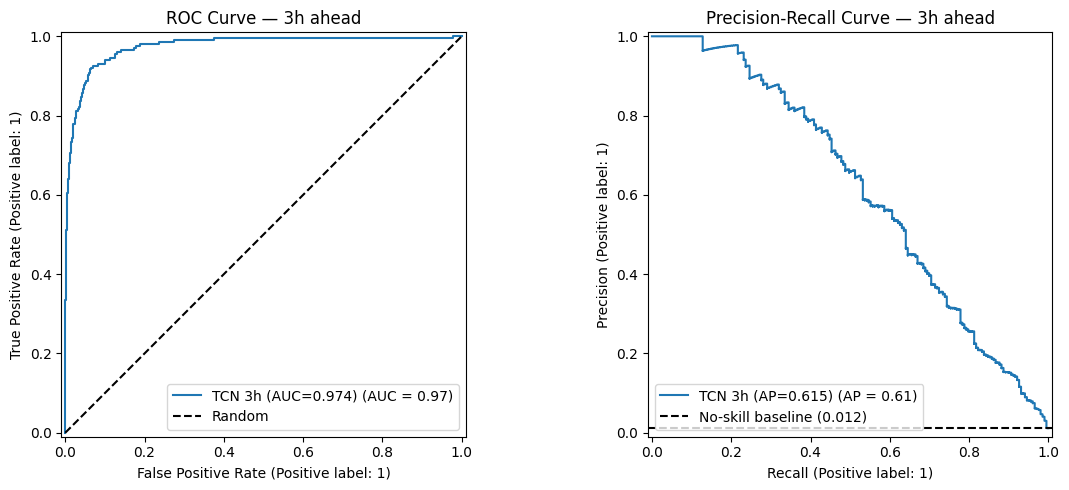

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y3_test, y3_prob, name=f"TCN 3h (AUC={roc_auc_3:.3f})", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve — 3h ahead")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y3_test, y3_prob, name=f"TCN 3h (AP={pr_auc_3:.3f})", ax=axes[1])
axes[1].axhline(y3_test.mean(), color="k", linestyle="--",
                label=f"No-skill baseline ({y3_test.mean():.3f})")
axes[1].set_title("Precision-Recall Curve — 3h ahead")
axes[1].legend()

plt.tight_layout()
plt.show()